In [2]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ==== Paths ====
train_image_dir = r"C:\Users\JAI\Downloads\archive (2)\guns-knives-yolo\guns-knives-yolo\train\images"
train_label_dir = r"C:\Users\JAI\Downloads\archive (2)\guns-knives-yolo\guns-knives-yolo\train\labels"
val_image_dir = r"C:\Users\JAI\Downloads\archive (2)\guns-knives-yolo\guns-knives-yolo\valid\images"
val_label_dir = r"C:\Users\JAI\Downloads\archive (2)\guns-knives-yolo\guns-knives-yolo\valid\labels"

In [3]:
# ==== HOG Parameters ====
hog_params = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys'
}
roi_size = (64, 128)  # Standard HOG size

# ==== Function to load HOG features from YOLO-labeled images ====
def load_data(image_dir, label_dir, hog_params, roi_size):
    features = []
    labels = []

    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in image_files:
        image_path = os.path.join(image_dir, img_file)
        label_path = os.path.join(label_dir, img_file.replace('.jpg', '.txt'))

        if not os.path.exists(label_path):
            continue

        image = cv2.imread(image_path)
        if image is None:
            continue

        h_img, w_img, _ = image.shape

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            try:
                cls, xc, yc, w, h = map(float, parts[:5])

                if int(cls) not in [0, 1]:
                    continue

                x1 = max(0, int((xc - w / 2) * w_img))
                y1 = max(0, int((yc - h / 2) * h_img))
                x2 = min(w_img, int((xc + w / 2) * w_img))
                y2 = min(h_img, int((yc + h / 2) * h_img))

                roi = image[y1:y2, x1:x2]
                if roi.shape[0] < 20 or roi.shape[1] < 20:
                    continue

                roi_resized = cv2.resize(roi, roi_size)
                roi_gray = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2GRAY)

                hog_feat = hog(roi_gray, **hog_params)
                features.append(hog_feat)
                labels.append(int(cls))

            except Exception as e:
                print("Skipping due to error:", e)
                continue

    return np.array(features), np.array(labels)

In [4]:
# ==== Load Training and Validation Data ====
print("Loading training data...")
X_train, y_train = load_data(train_image_dir, train_label_dir, hog_params, roi_size)
print("Loaded training samples:", len(X_train))

print("Loading validation data...")
X_val, y_val = load_data(val_image_dir, val_label_dir, hog_params, roi_size)
print("Loaded validation samples:", len(X_val))

# ==== Train the SVM Model ====
print("Training SVM...")
clf = SVC(kernel='linear', probability=True)
clf.fit(X_train, y_train)

# ==== Evaluate the Model ====
print("\n=== Evaluation ===")
print("Training Accuracy:", clf.score(X_train, y_train))
print("Validation Accuracy:", clf.score(X_val, y_val))

y_pred = clf.predict(X_val)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Gun", "Knife"]))



Loading training data...
Loaded training samples: 4585
Loading validation data...
Loaded validation samples: 1082
Training SVM...

=== Evaluation ===
Training Accuracy: 0.9949836423118866
Validation Accuracy: 0.8373382624768947

Classification Report:
              precision    recall  f1-score   support

         Gun       0.81      0.84      0.83       501
       Knife       0.86      0.83      0.85       581

    accuracy                           0.84      1082
   macro avg       0.84      0.84      0.84      1082
weighted avg       0.84      0.84      0.84      1082



In [5]:
def non_max_suppression_fast(boxes, overlapThresh=0.3):
    if len(boxes) == 0:
        return []
    
    boxes = np.array(boxes)
    pick = []
    
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = x1 + boxes[:,2]
    y2 = y1 + boxes[:,3]
    scores = boxes[:,5]
    
    idxs = np.argsort(scores)[::-1]
    
    while len(idxs) > 0:
        i = idxs[0]
        pick.append(i)
        
        xx1 = np.maximum(x1[i], x1[idxs[1:]])
        yy1 = np.maximum(y1[i], y1[idxs[1:]])
        xx2 = np.minimum(x2[i], x2[idxs[1:]])
        yy2 = np.minimum(y2[i], y2[idxs[1:]])
        
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        
        overlap = (w * h) / ((x2[i] - x1[i]) * (y2[i] - y1[i]) + 1e-6)
        
        idxs = np.delete(idxs, np.concatenate(([0], np.where(overlap > overlapThresh)[0] + 1)))
    
    return boxes[pick].astype("int")


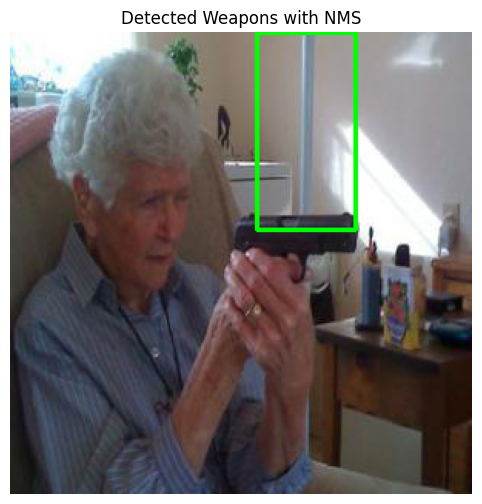

In [20]:
def detect_weapons_in_image(image_path, clf, hog_params, roi_size=(64, 128), step_size=32, nms_thresh=0.4):
    image = cv2.imread(image_path)
    orig_image = image.copy()
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    detected_boxes = []
    
    for y in range(0, image_gray.shape[0] - roi_size[1], step_size):
        for x in range(0, image_gray.shape[1] - roi_size[0], step_size):
            window = image_gray[y:y+roi_size[1], x:x+roi_size[0]]
            
            if window.shape[0] != roi_size[1] or window.shape[1] != roi_size[0]:
                continue
                
            features = hog(window, **hog_params).reshape(1, -1)
            prediction = clf.predict(features)
            confidence = clf.predict_proba(features).max()
            
            if confidence > 0.98:
                detected_boxes.append([x, y, roi_size[0], roi_size[1], prediction[0], confidence])
    
    # Apply NMS
    if len(detected_boxes) > 0:
        nms_boxes = non_max_suppression_fast(np.array(detected_boxes), overlapThresh=nms_thresh)
    else:
        nms_boxes = []
    
    # Draw final boxes
    for (x, y, w, h, cls, conf) in nms_boxes:
        label = "Gun" if cls == 0 else "Knife"
        cv2.rectangle(orig_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(orig_image, f"{label} ({conf:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    
    # Display results
    image_rgb = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Detected Weapons with NMS")
    plt.show()

# ==== Run detection on a test image ====
detect_weapons_in_image(r"C:\Users\JAI\Downloads\archive (2)\guns-knives-yolo\guns-knives-yolo\test\images\armas--629-_jpg.rf.9865b0168c261bbb57e93c4aa492610c.jpg", clf, hog_params, nms_thresh=0.4)


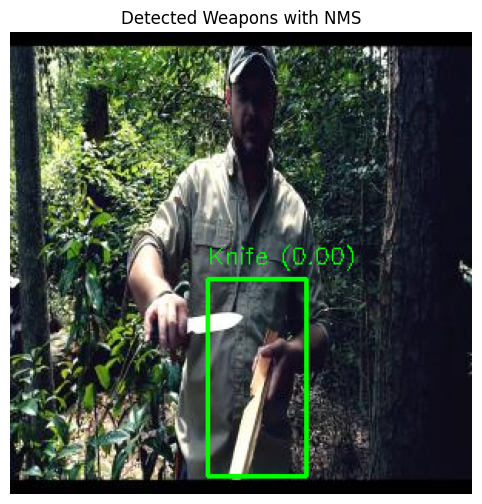

In [21]:
detect_weapons_in_image(r"C:\Users\JAI\Downloads\archive (2)\guns-knives-yolo\guns-knives-yolo\test\images\knife_1121_jpg.rf.b3a82f608ba13470de2cb459dc359187.jpg", clf, hog_params, nms_thresh=0.4)
